В ходе работы требуется находить и извлекать категории из описаний продуктов (**description**) и добавлять во вновь созданную колонку **clarification**. Категории были отобраны аналитиками и содержутся в файле **по мясу.docx**.

# Импорт библиотек

In [1]:
import re
import os 
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

pd.set_option('display.max_colwidth', 200)

# Загрузка данных

## Указание пути датасета и загрузка

In [2]:
datapath = '../../monitorings/meat/predictor/data/meat_dataset_v3.csv'

In [3]:
df = pd.read_csv(os.path.join(datapath), sep=';')

# Список категорий для разметки

In [4]:
valid_df = df.copy()

Список взят из **'по мясу.docx'** файла, сформированного аналитиками. Некоторые категории разбиты или изменены для составления регулярных выражений.

In [5]:
clarification_categories = [
    'замороженное',
    'охлажденное',
    'бк',
    'нк',
    'задние/задняя',
    'передние/передняя',
    'грубая',
    'мягкая',
    'становая',
    'внутренний/внутренняя',
    'корпусной',
    'кишечный',
    'chuck',
    '1 сорт',
    '2 сорт',
    'высший сорт',
    'экстра',
    'котлетное',
    'головной/головная',
    'компенсат',
    'односортное',
    'мясная',
    '1 кат',
    '2 кат',
    'быки',
    'коровы',
    'ленточное',
    'зачищен',
    'не зачищен',
    '70/30',
    '80/20',
    '50/50',
    '60/40',
    '90/10',
    'МО',
    'толстый',
    'тонкий',
    'без языка',
    'цельная',
    'ограбленная',
    'без шкуры',
    'на шкуре',
    'без хребта',
    'с хребтом',
    'копчиковые/копчиковый',
    'пищевая/пищевой',
    'суповая/суповой',
    'техническая/технический',
    'на хрящах',
    'без голяшки',
    'вертолет',
    'ленточное',
    'подлопаточное',
    'треугольник',
    'на ребре',
    'боковой/боковая',
    'без кожи – бк',
    'ск',
    '2 фаланги',
    '3 фаланги',
    'плечо',
    'хребтовая/хребтовой',
    'халяль',
    'мясокостный/мясокостная',
    'домашняя',
    'корнишон',
    'несушка',
    'малое',
    'мелкокусковое',
    'локтевая часть',
    'голени',
    '4 ребра',
    '8 ребер',
    'каре',
    'молодняк'
]

Далее создаём словарь **clarification_dict**, который имеет следующую структуру:  
- **ключ** - категория  
- **значение** - регулярное выражение  
  
Функция **find_categories** будет производить поиск в соответствии со словарём паттернов и возвращать все найденные значения в **clarification**

In [6]:
clarification_dict = {
    'замороженное': r'\bзам(?:ороженн(?:ый|ое|ые|ая))?\.?\b|зам\.\s*[.)]',
    'охлажденное': r'\bохл(?:ажд[её]нн(?:ый|ое|ые|ая))?\.?\b|охл\.\s*[.)]',

    # условились на том что 'бк' будут интерпретироваться и как 'без кожи' и как 'без кости' (в зависимости от контекста)
    'бк': r'(?:(?<!\w)бк(?!\w))|(?:без\s+кост\w*)|(?:без\s+кож\w*)',

    'нк': r'(?:(?<!\w)нк(?!\w))|(?:на\s+кост\w*)',
    'задние/задняя': r'\bзадн\w*\b',
    'передние/передняя': r'\bпередн\w*\b',
    'грубая': r'\bгруб\w*\b',
    'мягкая': r'\bмягк\w*\b',
    'становая': r'\bстанов\w*\b',
    'внутренний/внутренняя': r'\bвнутренн\w*',
    'корпусной': r'корпусн\w*',
    'кишечный': r'кишечн\w*',
    'chuck': r'(?:chuck|\bчак\b)',
    '1 сорт': r'(?:1\s+сорт|1сорт)',
    '2 сорт': r'(?:2\s+сорт|2сорт)',
    'высший сорт': r'высший\s+сорт',
    'экстра': r'экстра',
    'котлетное': r'\bкотлетн\w*\b',
    'головной/головная': r'головн\w*',
    'компенсат': r'компенсат\w*',
    'односортное': r'односортн\w*',
    'мясная': r'^(?!.*\b(первая|уральская)\s+мясная\s+компания\b).*\bмясн\w*(?!\s+(двор|дом|магнат))\b',
    '1 кат': r'1\s+кат',
    '2 кат': r'2\s+кат',
    'быки': r'\b(бык|быки)\b',
    'коровы': r'\b(корова|коровы)\b',
    'ленточное': r'\bленточн\w*\b', # в файле встречалось 2 раза
    'зачищен': r'\bзачищ\w*\b',
    'не зачищен': r'\bне\s+зачищ\w*\b',
    '70/30': r'70/30',
    '80/20': r'80/20',
    '50/50': r'50/50',
    '60/40': r'60/40',
    '90/10': r'90/10',
    'МО': r'(?:механ\w*\s+обвалк\w*)|(?:(?<!\w)мо(?!\w))|(?:(?<!\w)ммо(?!\w))|(?:мехобвалк\w*)',
    'толстый': r'толст\w*',
    'тонкий': r'тонк\w*',
    'без языка': r'без\s+язык\w*',
    'цельная': r'цельн\w*',
    'ограбленная': r'(?<!\bне)(?<!\bне\ )ограблен\w*', # исключаем неограбленная и не ограбленная
    'без шкуры': r'без\s+шкур\w*',
    'на шкуре': r'на\s+шкур\w*',
    'без хребта': r'без\s+хребт\w*',
    'с хребтом': r'с\s+хребт\w*', 
    'копчиковые/копчиковый': r'копчиков\w*',
    'пищевая/пищевой': r'(?<!\S)(пищев(?:ая|ой))(?!\s+промышлен\w+)(?=\b)',
    'суповая/суповой': r'супов\w*',
    'техническая/технический': r'техническ\w*',
    'на хрящах': r'на\s+хрящ\w*',
    'без голяшки': r'без\s+голяшк\w*',
    'вертолет': r'\bвертол[её]т\w*\b',
    'подлопаточное': r'подлопаточн\w*',
    'треугольник': r'треугольник\w*',
    'на ребре': r'на\s+р[её]бр\w*',
    'боковой/боковая': r'боков\w*',
    'ск': r'(?:(?<!\w)ск(?!\w))|(?:с\s+кож\w*)',
    '2 фаланги': r'2\s+фаланг\w*',
    '3 фаланги': r'3\s+фаланг\w*',
    'плечо': r'плеч\w*',
    'хребтовая/хребтовой': r'хребтов\w*',
    'халяль': r'\bхаляль\b',
    'мясокостный/мясокостная': r'мясокостн\w*',
    'домашняя': r'(?<!по)(?<!по-)(?<!по\ )домашн\w*',
    'корнишон': r'корнишон\w*',
    'несушка': r'несушк\w*',
    'малое': r'мал\w*',
    'мелкокусковое': r'мелкокусков\w*',
    'локтевая часть': r'локтев\w*',
    'голени': r'голен\w*',
    '4 ребра': r'4\s+р[её]бр\w*',
    '8 ребер': r'8\s+р[её]бер',
    'каре': r'\bкаре\b',
    'молодняк': r'молодняк\w*'
}

# функция поиска по регулярному выражению в ключе
def find_categories(text, pattern_dict):
    found_keys = []
    for key, pattern in pattern_dict.items():
        if re.search(pattern, text, flags=re.IGNORECASE):
            found_keys.append(key)
    return found_keys

valid_df['clarification'] = valid_df['description'].apply(
    lambda x: find_categories(x, clarification_dict)
)

print('Количество записей с уточнениями:', len(valid_df[valid_df['clarification'].str.len() > 0]))

Количество записей с уточнениями: 28481


# Валидация

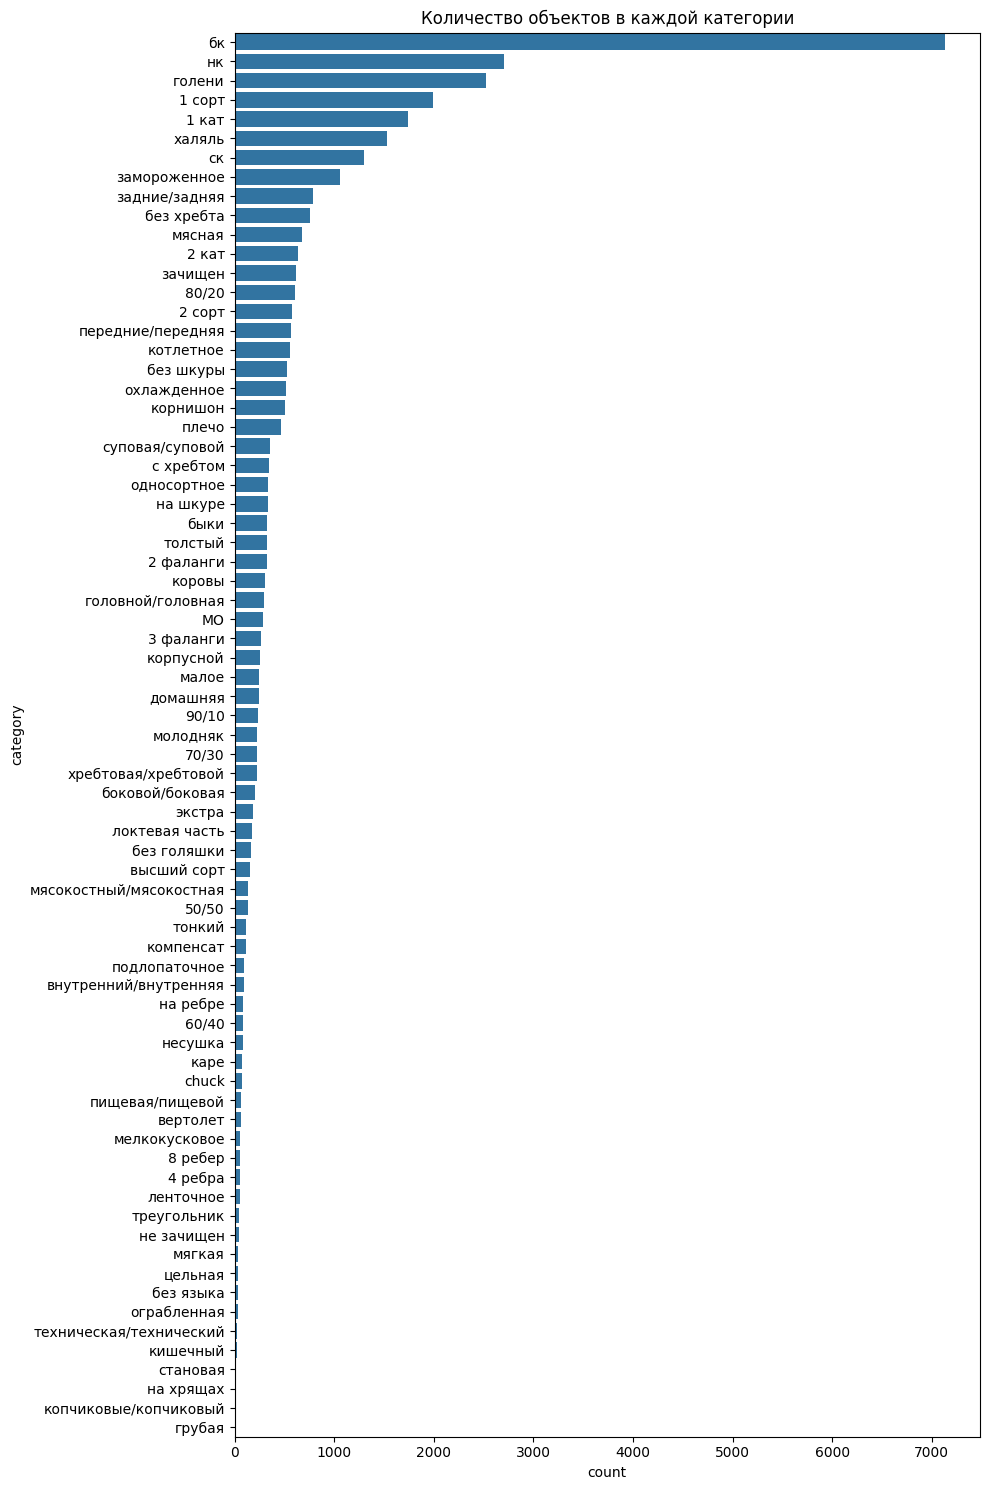

In [7]:
# визуализация баланса извлеченных классов
stats = {}
for cat in clarification_dict.keys():
    mask = valid_df[(valid_df['clarification'].apply(lambda x: cat in x))].index
    stats[cat] = valid_df.loc[mask].shape[0]

stats_df = pd.DataFrame(stats.items(), columns=['category', 'count']).sort_values(by='count', ascending=False)

plt.figure(figsize=(10, 15))
sns.barplot(x='count', y='category', data=stats_df, orient='h')
plt.title('Количество объектов в каждой категории')
plt.tight_layout()
plt.show()

In [8]:
# выведем список категорий
s = []
max_length = max(len(f"{key}: {stats[key]}") for key in stats.keys())

for key in sorted(stats.keys(), key=lambda x: stats[x], reverse=True):
    stat_str = f"{key}: {stats[key]}"
    s.append(stat_str.ljust(max_length))
    if len(s) > 5:
        string = " | ".join(s)
        print(string)
        s = []

бк: 7127                     | нк: 2706                     | голени: 2524                 | 1 сорт: 1997                 | 1 кат: 1741                  | халяль: 1532                
ск: 1300                     | замороженное: 1057           | задние/задняя: 792           | без хребта: 760              | мясная: 674                  | 2 кат: 640                  
зачищен: 620                 | 80/20: 608                   | 2 сорт: 577                  | передние/передняя: 563       | котлетное: 553               | без шкуры: 523              
охлажденное: 521             | корнишон: 507                | плечо: 463                   | суповая/суповой: 361         | с хребтом: 342               | односортное: 341            
на шкуре: 334                | быки: 330                    | толстый: 327                 | 2 фаланги: 323               | коровы: 303                  | головной/головная: 291      
МО: 285                      | 3 фаланги: 261               | корпусной: 256    

С помощью следующих выражениий категории будут просматриваться вручную. Необходимые правки будут внесены в словарь **clarification_dict**.

In [9]:
# строка для поиска по извлечённым категориям
valid_df[valid_df['clarification'].apply(lambda x: 'задние/задняя' in x)].sample(15)

,Unnamed: 0,product,description,product_type,clarification
1807,1807,говядина,задние части (в 3 частях - анатом.проп.),задние части,[задние/задняя]
3626,3626,говядина,"голяшка бк,задние,гост",голяшка,"[бк, задние/задняя]"
1180,1180,говядина,голяшка бк задняя зачищ.,голяшка,"[бк, задние/задняя, зачищен]"
48049,48049,цыпленок,четвертина задняя гост чамзинкаподл. (8),четвертина,[задние/задняя]
16460,16460,свинина,"ноги (задние).,",ноги,[задние/задняя]
9634,9634,говядина,"тазобедренный отруб задние,компенсат",тазобедренный отруб,"[задние/задняя, компенсат]"
6412,6412,говядина,задние части 3 куска тмк тф,задние части,[задние/задняя]
35256,35256,цыпленок,четвертина задняя вал,четвертина,[задние/задняя]
2194,2194,говядина,задние части внутр.,задние части,[задние/задняя]
341,341,говядина,задние части компннсат,задние части,[задние/задняя]


In [10]:
# строка для поиска по вхождению слова в описание
valid_df[valid_df['description'].str.contains('на кости')]

,Unnamed: 0,product,description,product_type,clarification
59601,59601,кура,мясо на кости (лоток),кость,[нк]
59602,59602,кура,мясо на кости халяль (лоток),кость,"[нк, халяль]"


В ходе валидации внесены доплнения/исключения:  
- мясная: исключения мясной двор, мясной дом, мясной магнат, первая мясная компания, уральская мясная компания
- ограбленная: есть противоположный класс **неограбленная**
- зачищен, не зачищен, охлаждённое, замороженное: могут встречаться различные сокращения и окончания точкой **.**
- в некоторых классах добавлен просмотр буквы **ё**
- пищевая/пищевой: исключена 'пищевая промышленность'
- механической обвалки: мехобвалки
- chuck: чак
- домашняя: исключено 'по-домашнему'
- 1 и 2 сорт добавлено 1сорт 2сорт  

Категория А и категория Б являются синонимами 1 и 2 категории ???

# Скрипт для обновления БД

```python
import re
import json
import time
import logging
from typing import List, Optional, Dict
from utils.settings import secrets as s
from sqlalchemy import (
    MetaData, Table, text, update, bindparam, func, select,
    create_engine, and_
)
from sqlalchemy.orm import sessionmaker

# Настройка логирования
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)

logger = logging.getLogger(__name__)

BATCH_SIZE = 50000  

engine = create_engine(
    f'mysql+pymysql://{s.db_user}:{s.db_password}@{s.db_host}:{s.db_port}/{s.db_name}',
    pool_pre_ping=True,
    pool_size=5,
    max_overflow=10,
    pool_recycle=3600
)
Session = sessionmaker(bind=engine)

clarification_dict = {
    'замороженное': r'\bзам(?:ороженн(?:ый|ое|ые|ая))?\.?\b|зам\.\s*[.)]',
    'охлажденное': r'\bохл(?:ажд[её]нн(?:ый|ое|ые|ая))?\.?\b|охл\.\s*[.)]',
    'бк': r'(?:(?<!\w)бк(?!\w))|(?:без\s+кост\w*)|(?:без\s+кож\w*)',
    'нк': r'(?:(?<!\w)нк(?!\w))|(?:на\s+кост\w*)',
    'задние/задняя': r'\bзадн\w*\b',
    'передние/передняя': r'\bпередн\w*\b',
    'грубая': r'\bгруб\w*\b',
    'мягкая': r'\bмягк\w*\b',
    'становая': r'\bстанов\w*\b',
    'внутренний/внутренняя': r'\bвнутренн\w*',
    'корпусной': r'корпусн\w*',
    'кишечный': r'кишечн\w*',
    'chuck': r'(?:chuck|\bчак\b)',
    '1 сорт': r'(?:1\s+сорт|1сорт)',
    '2 сорт': r'(?:2\s+сорт|2сорт)',
    'высший сорт': r'высший\s+сорт',
    'экстра': r'экстра',
    'котлетное': r'\bкотлетн\w*\b',
    'головной/головная': r'головн\w*',
    'компенсат': r'компенсат\w*',
    'односортное': r'односортн\w*',
    'мясная': r'^(?!.*\b(первая|уральская)\s+мясная\s+компания\b).*\bмясн\w*(?!\s+(двор|дом|магнат))\b',
    '1 кат': r'1\s+кат',
    '2 кат': r'2\s+кат',
    'быки': r'\b(бык|быки)\b',
    'коровы': r'\b(корова|коровы)\b',
    'ленточное': r'\bленточн\w*\b',
    'зачищен': r'\bзачищ\w*\b',
    'не зачищен': r'\bне\s+зачищ\w*\b',
    '70/30': r'70/30',
    '80/20': r'80/20',
    '50/50': r'50/50',
    '60/40': r'60/40',
    '90/10': r'90/10',
    'МО': r'(?:механ\w*\s+обвалк\w*)|(?:(?<!\w)мо(?!\w))|(?:(?<!\w)ммо(?!\w))|(?:мехобвалк\w*)',
    'толстый': r'толст\w*',
    'тонкий': r'тонк\w*',
    'без языка': r'без\s+язык\w*',
    'цельная': r'цельн\w*',
    'ограбленная': r'(?<!\bне)(?<!\bне\ )ограблен\w*',
    'без шкуры': r'без\s+шкур\w*',
    'на шкуре': r'на\s+шкур\w*',
    'без хребта': r'без\s+хребт\w*',
    'с хребтом': r'с\s+хребт\w*',
    'копчиковые/копчиковый': r'копчиков\w*',
    'пищевая/пищевой': r'(?<!\S)(пищев(?:ая|ой))(?!\s+промышлен\w+)(?=\b)',
    'суповая/суповой': r'супов\w*',
    'техническая/технический': r'техническ\w*',
    'на хрящах': r'на\s+хрящ\w*',
    'без голяшки': r'без\s+голяшк\w*',
    'вертолет': r'\bвертол[её]т\w*\b',
    'подлопаточное': r'подлопаточн\w*',
    'треугольник': r'треугольник\w*',
    'на ребре': r'на\s+р[её]бр\w*',
    'боковой/боковая': r'боков\w*',
    'ск': r'(?:(?<!\w)ск(?!\w))|(?:с\s+кож\w*)',
    '2 фаланги': r'2\s+фаланг\w*',
    '3 фаланги': r'3\s+фаланг\w*',
    'плечо': r'плеч\w*',
    'хребтовая/хребтовой': r'хребтов\w*',
    'халяль': r'\bхаляль\b',
    'мясокостный/мясокостная': r'мясокостн\w*',
    'домашняя': r'(?<!по)(?<!по-)(?<!по\ )домашн\w*',
    'корнишон': r'корнишон\w*',
    'несушка': r'несушк\w*',
    'малое': r'мал\w*',
    'мелкокусковое': r'мелкокусков\w*',
    'локтевая часть': r'локтев\w*',
    'голени': r'голен\w*',
    '4 ребра': r'4\s+р[её]бр\w*',
    '8 ребер': r'8\s+р[её]бер',
    'каре': r'\bкаре\b',
    'молодняк': r'молодняк\w*'
}

# Предварительная компиляция регулярных выражений
compiled_clarification_dict = {
    key: re.compile(pattern, flags=re.IGNORECASE)
    for key, pattern in clarification_dict.items()
}

def find_product_details_in_text(text: str, pattern_dict: dict) -> Optional[List[str]]:
    """Ищет в тексте все совпадения с паттернами из словаря."""
    if not isinstance(text, str) or not text.strip():
        return None
    
    found_keys = [
        key for key, pattern in pattern_dict.items()
        if pattern.search(text)
    ]
    
    return found_keys if found_keys else None


def update_product_details(session, batch_size=5000):
    """
    Обновление столбца 'product_details' в таблице мясных мониторингов.
    
    Args:
        session: SQLAlchemy session
        batch_size: Размер батча для обработки
    """
    metadata = MetaData()
    db_table = Table(s.raw_table_meat, metadata, autoload_with=session.get_bind())
    
    logger.info("Начинаем анализ таблицы...")
    
    # кол-во записей
    count_stmt = select(func.count(db_table.c.id)).where(
        and_(
            db_table.c.description.isnot(None),
            db_table.c.description != ''
        )
    )
    total_records = session.execute(count_stmt).scalar()
    logger.info(f"Найдено {total_records} записей с описаниями для обработки")
    
    if total_records == 0:
        logger.info("Нет записей для обработки")
        return {
            'total_records': 0,
            'unique_descriptions': 0,
            'descriptions_with_details': 0,
            'total_updated': 0
        }
    
    # переменные для статистики
    total_updated = 0
    total_unique_descriptions = set()
    total_descriptions_with_details = 0
    processed_records = 0
    
    # обработка таблицы будет производиться батчами
    offset = 0
    batch_num = 1
    
    while offset < total_records:
        logger.info(f"Обработка батча {batch_num} (записи {offset + 1}-{min(offset + batch_size, total_records)} из {total_records})")
        
        # создание батча
        batch_stmt = select(
            db_table.c.id,
            db_table.c.description
        ).where(
            and_(
                db_table.c.description.isnot(None),
                db_table.c.description != ''
            )
        ).limit(batch_size).offset(offset)
        
        batch_records = session.execute(batch_stmt).fetchall()
        
        if not batch_records:
            break
        
        # уникальные описания в батче
        batch_description_to_ids = {}
        for row in batch_records:
            description_clean = row.description.lower().strip()
            total_unique_descriptions.add(description_clean)
            
            if description_clean not in batch_description_to_ids:
                batch_description_to_ids[description_clean] = {
                    'original': row.description,
                    'ids': []
                }
            batch_description_to_ids[description_clean]['ids'].append(row.id)

        # поиск product_details
        batch_updates = []
        batch_descriptions_with_details = 0
        
        for description_clean, desc_info in batch_description_to_ids.items():
            product_details = find_product_details_in_text(
                desc_info['original'], 
                compiled_clarification_dict
            )
            
            if product_details:
                batch_descriptions_with_details += 1
                details_json = json.dumps(product_details, ensure_ascii=False)
                
                # Добавляем все ID с этим описанием для обновления
                for record_id in desc_info['ids']:
                    batch_updates.append({
                        'b_id': record_id,
                        'b_details': details_json
                    })
        
        # обновление записей батча
        batch_updated = 0
        if batch_updates:
            stmt_update = (
                update(db_table)
                .where(db_table.c.id == bindparam('b_id'))
                .values(product_details=bindparam('b_details'))
            )
            
            result = session.execute(stmt_update, batch_updates)
            batch_updated = result.rowcount
            
            # Коммитим изменения после каждого батча
            session.commit()
            logger.info(f"Батч {batch_num}: найдены детали в {batch_descriptions_with_details} описаниях, обновлено {batch_updated} записей")
        else:
            logger.info(f"Батч {batch_num}: детали не найдены, записи не обновлены")
        
        # Обновляем статистику
        total_updated += batch_updated
        total_descriptions_with_details += batch_descriptions_with_details
        processed_records += len(batch_records)
        
        # Переходим к следующему батчу
        offset += batch_size
        batch_num += 1
    
    logger.info(f"Обработка завершена. Обработано {processed_records} записей в {batch_num - 1} батчах")
    
    return {
        'total_records': total_records,
        'unique_descriptions': len(total_unique_descriptions),
        'descriptions_with_details': total_descriptions_with_details,
        'total_updated': total_updated
    }

# START ============================================================
logger.info("Запуск обновления product_details для таблицы: " + s.raw_table_meat)

start_time = time.time()

max_retries = 3
retry_delay = 60

for attempt in range(max_retries):
    session = Session()
    try:
        # Устанавливаем параметры сессии для оптимизации
        session.execute(text("SET SESSION innodb_lock_wait_timeout = 50"))
        try:
            session.execute(text("SET SESSION tx_isolation = 'READ-COMMITTED'"))
        except:
            logger.warning("Не удалось установить уровень изоляции транзакций")
        
        result = update_product_details(session, BATCH_SIZE)
        end_time = time.time()
        execution_time = end_time - start_time
        
        logger.info("=" * 60)
        logger.info("ОБНОВЛЕНИЕ ЗАВЕРШЕНО УСПЕШНО")
        logger.info(f"Время выполнения: {execution_time:.2f} секунд")
        logger.info(f"Размер батча: {BATCH_SIZE} записей")
        logger.info(f"Всего записей: {result['total_records']}")
        logger.info(f"Уникальных описаний: {result['unique_descriptions']}")
        logger.info(f"Описаний с деталями: {result['descriptions_with_details']}")
        logger.info(f"Обновлено записей в БД: {result['total_updated']}")
        logger.info("=" * 60)
        
        break
        
    except Exception as e:
        session.rollback()
        logger.error(f"Ошибка при выполнении обновления, попытка {attempt + 1}: {e}")
        if attempt < max_retries - 1:
            logger.info(f"Повторная попытка через {retry_delay} секунд...")
            time.sleep(retry_delay)
        else:
            raise Exception(f"Обновление не удалось после {max_retries} попыток")
    finally:
        session.close()

logger.info(f"Программа завершена") 
```